# Hafta 1 — Birinci Mertebeden Adi Diferansiyel Denklemler

> **Bilim İnsanları ve Mühendisler için Diferansiyel Denklemler**  
> *Değişkenlerine ayrılabilir denklemlerden tam formlara — her yöntem kodlanmadan önce türetilir.*

---

## Öğrenme Hedefleri

Bu not defterinin sonunda şunları yapabileceksiniz:

1. Birinci mertebeden bir ADD'yi türüne göre sınıflandırmak (ayrılabilir, doğrusal, Bernoulli, tam)
2. Doğrusal ADD'ler için **integral çarpanını** türetmek ve uygulamak
3. **Bernoulli denklemlerini** $v = y^{1-n}$ dönüşümüyle çözmek
4. Tamlığı sınamak ve bir **potansiyel fonksiyon** $F(x,y)$ kurmak
5. Sıfırdan bir **yön alanı** çizici oluşturmak
6. Çözüm ailelerini geometrik olarak görselleştirmek


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

---

## 1. Ayrılabilir ADD'ler

Birinci mertebeden bir ADD, aşağıdaki gibi yazılabiliyorsa **değişkenlerine ayrılabilir**dir:

$$\frac{dy}{dx} = g(x)\,h(y)$$

Değişkenleri ayırıp her iki tarafı integralleyerek:

$$\int \frac{dy}{h(y)} = \int g(x)\,dx + C$$

### Örnek 1.1 — Üstel Azalma

$$\frac{dy}{dx} = -k\,y, \quad y(0) = y_0$$

Ayırma: $\dfrac{dy}{y} = -k\,dx$, integralleme: $\ln|y| = -kx + C_1$, üstel alma: $y(x) = y_0\,e^{-kx}$.

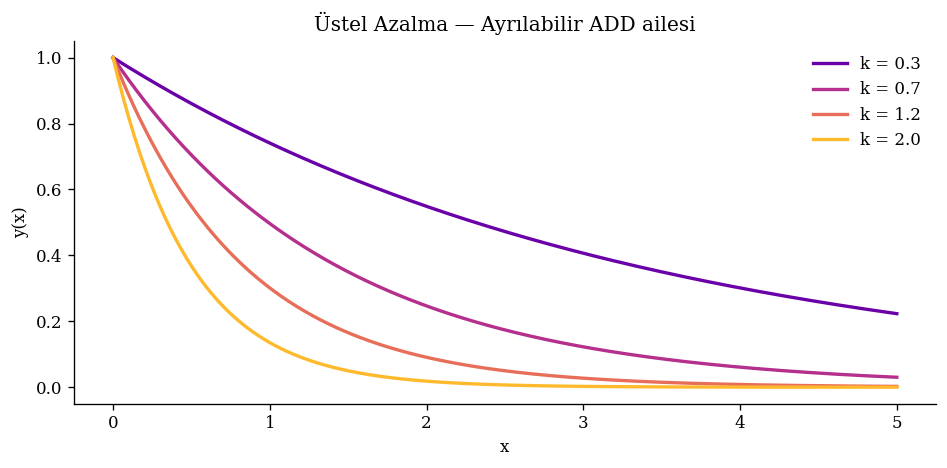

In [2]:
x = np.linspace(0, 5, 300)
k_degerleri = [0.3, 0.7, 1.2, 2.0]
y0 = 1.0

fig, ax = plt.subplots(figsize=(8, 4))
renkler = cm.plasma(np.linspace(0.2, 0.85, len(k_degerleri)))
for k, c in zip(k_degerleri, renkler):
    ax.plot(x, y0 * np.exp(-k * x), color=c, lw=2, label=f'k = {k}')

ax.set_xlabel('x'); ax.set_ylabel('y(x)')
ax.set_title('Üstel Azalma — Ayrılabilir ADD ailesi')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 2. Doğrusal Birinci Mertebeden ADD'ler ve İntegral Çarpanı

Standart form:

$$\frac{dy}{dx} + P(x)\,y = Q(x)$$

Her iki tarafı **integral çarpanı** $\mu(x) = e^{\int P(x)\,dx}$ ile çarpın:

$$\frac{d}{dx}\bigl[\mu(x)\,y\bigr] = \mu(x)\,Q(x)$$

İntegralleyerek:

$$\boxed{y(x) = \frac{1}{\mu(x)}\left[\int \mu(x)\,Q(x)\,dx + C\right]}$$

### Uygulama — Sayısal İntegral Çarpanı Çözücüsü

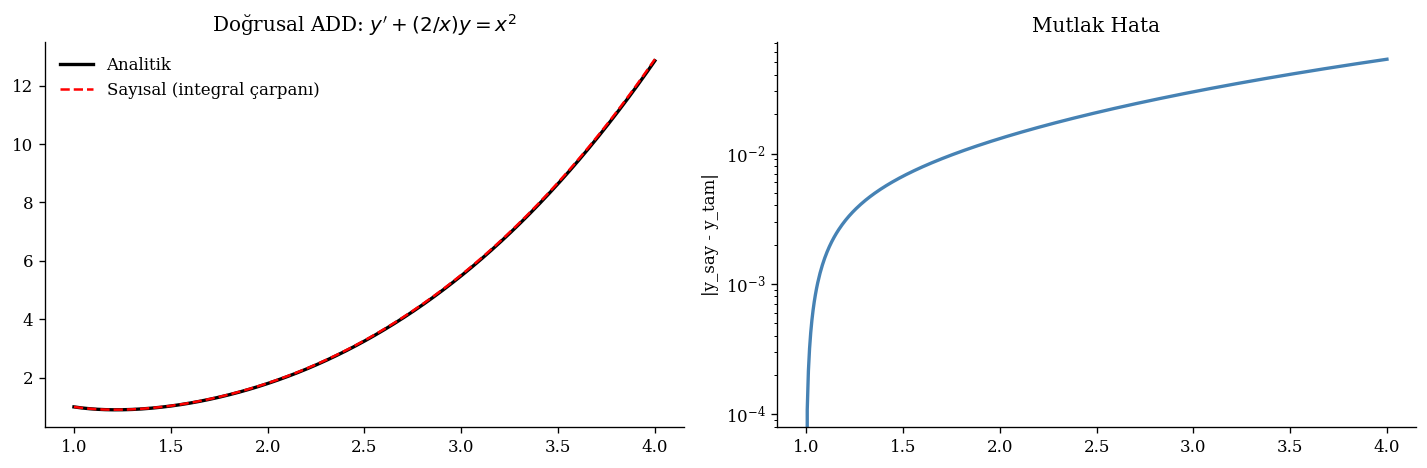

Maksimum mutlak hata: 5.30e-02


In [3]:
def integral_carpani_cozucu(P_fonk, Q_fonk, x_araligi, y0, n=500):
    """
    y' + P(x)y = Q(x) denklemini integral çarpanı yöntemiyle çözer.
    İntegraller kümülatif yamuk kuralı ile yaklaşık hesaplanır.
    """
    x = np.linspace(x_araligi[0], x_araligi[1], n)
    dx = x[1] - x[0]

    P_degerleri = np.array([P_fonk(xi) for xi in x])
    log_mu = np.cumsum(P_degerleri) * dx          # P(x) integrali
    mu = np.exp(log_mu)

    muQ = mu * np.array([Q_fonk(xi) for xi in x])
    integral_muQ = np.cumsum(muQ) * dx            # mu*Q integrali

    C = mu[0] * y0 - integral_muQ[0]              # başlangıç koşulunu uygula
    y = (integral_muQ + C) / mu
    return x, y


# Örnek: y' + (2/x)y = x^2,  y(1) = 1
# Analitik: y(x) = x^3/5 + 4/(5x^2)
P = lambda x: 2.0 / x
Q = lambda x: x**2
y_tam = lambda x: x**3 / 5.0 + 4.0 / (5.0 * x**2)

x_say, y_say = integral_carpani_cozucu(P, Q, x_araligi=(1, 4), y0=1.0)
x_tam = np.linspace(1, 4, 300)

fig, eksenler = plt.subplots(1, 2, figsize=(12, 4))
eksenler[0].plot(x_tam, y_tam(x_tam), 'k-', lw=2, label='Analitik')
eksenler[0].plot(x_say, y_say, 'r--', lw=1.5, label='Sayısal (integral çarpanı)')
eksenler[0].set_title("Doğrusal ADD: $y' + (2/x)y = x^2$")
eksenler[0].legend(frameon=False)

hata = np.abs(y_say - y_tam(x_say))
eksenler[1].semilogy(x_say, hata, color='steelblue', lw=2)
eksenler[1].set_title('Mutlak Hata')
eksenler[1].set_ylabel('|y_say - y_tam|')

plt.tight_layout(); plt.show()
print(f"Maksimum mutlak hata: {hata.max():.2e}")

---

## 3. Bernoulli Denklemleri

Bir **Bernoulli denklemi** şu forma sahiptir:

$$\frac{dy}{dx} + P(x)\,y = Q(x)\,y^n, \quad n \neq 0, 1$$

$v = y^{1-n}$ dönüşümü (her iki tarafı $y^n$'e bölüp yerine koyma) şunu verir:

$$\frac{dv}{dx} + (1-n)P(x)\,v = (1-n)Q(x)$$

ki bu standart bir **doğrusal** ADD'dir.

### Örnek 3.1 — Lojistik Büyüme

$$\frac{dy}{dt} = r\,y\left(1 - \frac{y}{K}\right)$$

Bu, $n=2$ için bir Bernoulli denklemidir.  
Analitik çözüm: $y(t) = \dfrac{K\,y_0}{y_0 + (K - y_0)\,e^{-rt}}$

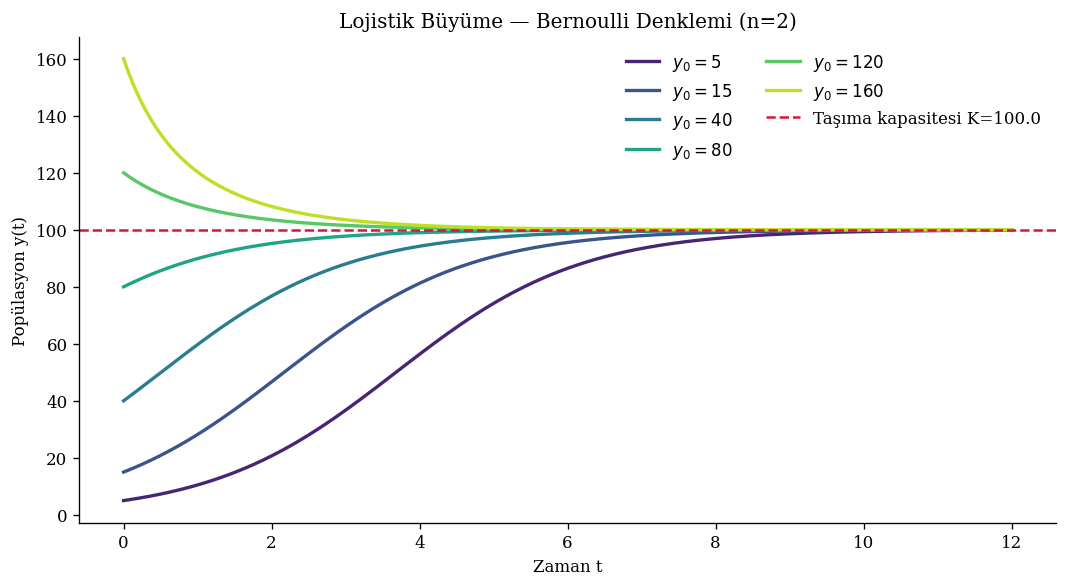

In [4]:
def lojistik(t, y0, r, K):
    return K * y0 / (y0 + (K - y0) * np.exp(-r * t))

t = np.linspace(0, 12, 400)
K, r = 100.0, 0.8
y0_degerleri = [5, 15, 40, 80, 120, 160]

fig, ax = plt.subplots(figsize=(9, 5))
renkler = cm.viridis(np.linspace(0.1, 0.9, len(y0_degerleri)))

for y0, c in zip(y0_degerleri, renkler):
    ax.plot(t, lojistik(t, y0, r, K), color=c, lw=2, label=f'$y_0={y0}$')

ax.axhline(K, color='crimson', ls='--', lw=1.5, label=f'Taşıma kapasitesi K={K}')
ax.set_xlabel('Zaman t'); ax.set_ylabel('Popülasyon y(t)')
ax.set_title('Lojistik Büyüme — Bernoulli Denklemi (n=2)')
ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

---

## 4. Tam Denklemler

$M(x,y)\,dx + N(x,y)\,dy = 0$ ADD'si **tam**dır ancak ve ancak:

$$\frac{\partial M}{\partial y} = \frac{\partial N}{\partial x}$$

Tam ise, $\nabla F = (M, N)$ olacak şekilde bir $F(x,y)$ vardır. Genel çözüm $F(x,y) = C$'dir.

**F'nin bulunması:**
1. $M$'yi $x$'e göre integralle: $F = \int M\,dx + g(y)$
2. $F$'yi $y$'ye göre türevle, $N$'ye eşitle, $g'(y)$ için çöz
3. $g(y)$'yi elde etmek için $g'(y)$'yi integralle

In [5]:
def tamlik_kontrolu(M_fonk, N_fonk, x0=1.0, y0=1.0, h=1e-5):
    """Sonlu fark kısmi türevleri ile tamlığı sayısal olarak doğrular."""
    dM_dy = (M_fonk(x0, y0+h) - M_fonk(x0, y0-h)) / (2*h)
    dN_dx = (N_fonk(x0+h, y0) - N_fonk(x0-h, y0)) / (2*h)
    tam_mi = np.isclose(dM_dy, dN_dx, atol=1e-6)
    print(f"  ∂M/∂y = {dM_dy:.8f}")
    print(f"  ∂N/∂x = {dN_dx:.8f}")
    print(f"  Tam: {tam_mi}")
    return tam_mi

# --- Durum 1: TAM ---
# (2xy + y^2)dx + (x^2 + 2xy)dy = 0
# F(x,y) = x^2*y + xy^2  =>  çözüm: x^2*y + xy^2 = C
print("Durum 1: (2xy + y²)dx + (x² + 2xy)dy = 0")
M1 = lambda x, y: 2*x*y + y**2
N1 = lambda x, y: x**2 + 2*x*y
tamlik_kontrolu(M1, N1)

print()

# --- Durum 2: TAM DEĞİL ---
print("Durum 2: x*dx + x*dy = 0  (tam değil)")
M2 = lambda x, y: x
N2 = lambda x, y: x
tamlik_kontrolu(M2, N2)

Durum 1: (2xy + y²)dx + (x² + 2xy)dy = 0
  ∂M/∂y = 4.00000000
  ∂N/∂x = 4.00000000
  Tam: True

Durum 2: x*dx + x*dy = 0  (tam değil)
  ∂M/∂y = 0.00000000
  ∂N/∂x = 1.00000000
  Tam: False


np.False_

---

## 5. Yön Alanları — Sıfırdan

Bir **yön alanı** (eğim alanı), her ızgara noktası $(x_i, y_j)$'de eğimi $f(x_i, y_j)$ olan birim teğet vektörü çizer; böylece tüm çözüm ailesinin geometrik bir portresini verir.

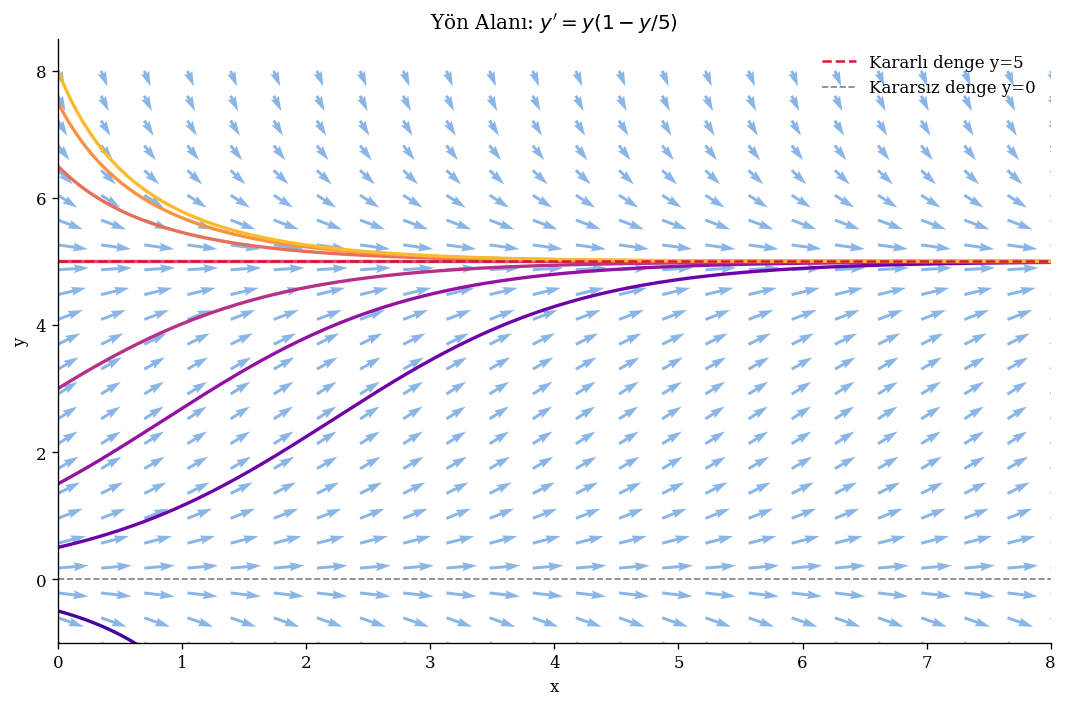

In [6]:
def yon_alani(f, x_araligi, y_araligi, nx=24, ny=24, ax=None, renk='#4a90d9', alpha=0.65):
    """dy/dx = f(x, y) için normalize edilmiş ok (quiver) kullanarak yön alanı çizer."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    x_degerleri = np.linspace(*x_araligi, nx)
    y_degerleri = np.linspace(*y_araligi, ny)
    X, Y = np.meshgrid(x_degerleri, y_degerleri)
    DX = np.ones_like(X)
    DY = f(X, Y)
    norm = np.sqrt(DX**2 + DY**2) + 1e-12
    DX /= norm; DY /= norm
    olcek = (x_araligi[1] - x_araligi[0]) / nx * 0.75
    ax.quiver(X, Y, DX * olcek, DY * olcek,
              angles='xy', scale_units='xy', scale=1,
              color=renk, alpha=alpha, width=0.003, headwidth=3)
    return ax

def euler_iz(f, x0, y0, x_son, h=0.05):
    """Belirli bir çözüm eğrisini üst üste bindirmek için ileri Euler integrasyonu."""
    xs, ys = [x0], [y0]
    x, y = x0, y0
    while x < x_son - h/2:
        y += h * f(x, y)
        x += h
        xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)


# --- Lojistik ADD faz portresi ---
f_lojistik = lambda x, y: y * (1 - y / 5.0)

fig, ax = plt.subplots(figsize=(9, 6))
yon_alani(f_lojistik, x_araligi=(0, 8), y_araligi=(-1, 8), ax=ax)

bk_degerleri = [-0.5, 0.5, 1.5, 3.0, 5.0, 6.5, 7.5, 8.0]
renkler = cm.plasma(np.linspace(0.1, 0.85, len(bk_degerleri)))
for y0_bk, c in zip(bk_degerleri, renkler):
    xs, ys = euler_iz(f_lojistik, x0=0, y0=y0_bk, x_son=8, h=0.02)
    ax.plot(xs, ys, color=c, lw=2)

ax.axhline(5, color='crimson', ls='--', lw=1.5, label='Kararlı denge y=5')
ax.axhline(0, color='gray', ls='--', lw=1.0, label='Kararsız denge y=0')
ax.set_xlim(0, 8); ax.set_ylim(-1, 8.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title("Yön Alanı: $y' = y(1 - y/5)$")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 6. Homojen Birinci Mertebeden Denklemler

Birinci mertebeden bir ADD, aşağıdaki gibi yazılabiliyorsa (klasik anlamda) **homojen**dir:

$$\frac{dy}{dx} = F\!\left(\frac{y}{x}\right)$$

Temel gözlem, $F$'nin yalnızca $v = y/x$ **oranına** bağlı olmasıdır. Dönüşüm

$$v = \frac{y}{x} \implies y = vx \implies y' = v + x\,v'$$

denklemi $v(x)$ cinsinden **ayrılabilir** bir ADD'ye dönüştürür:

$$v + x\,v' = F(v) \implies \frac{dv}{F(v)-v} = \frac{dx}{x}$$

**Örnek:** $y' = \dfrac{x^2 + y^2}{xy}$

Pay ve paydayı $x^2$'ye bölün:
$$y' = \frac{1 + (y/x)^2}{y/x} = F(v),\quad v = y/x$$
Dönüşüm ve integralleme sonrası: $y^2 = x^2(2\ln|x| + C)$.

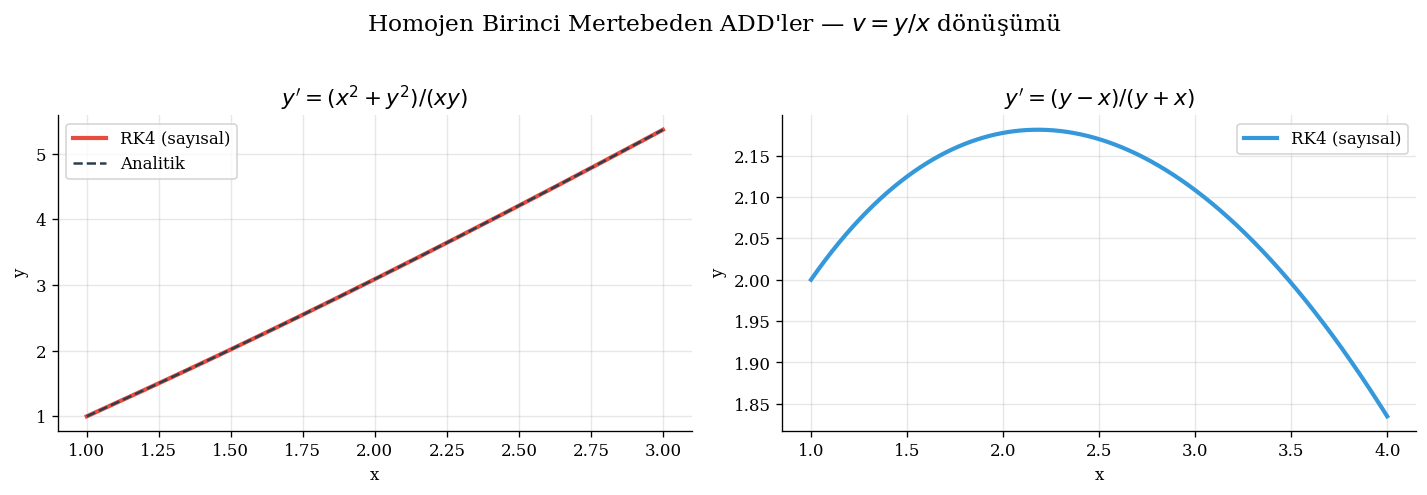

Analitik çözüme karşı maksimum mutlak hata (Örnek 1): 4.29e-07


In [7]:
def homojen_odd_coz(F, x0, y0, x_son, n=1000):
    """
    Homojen birinci mertebeden bir ADD'yi  dy/dx = F(y/x)
    v = y/x dönüşümüyle ayrılabilir forma indirgeyerek çözer.
    Dönüştürülmüş denklem üzerinde RK4 kullanır:
        dv/dx = (F(v) - v) / x
    Parametreler
    ----------
    F      : çağrılabilir  F(v), burada v = y/x
    x0,y0  : başlangıç koşulu (x0 != 0)
    x_son  : integrasyon aralığının sonu
    n      : adım sayısı
    """
    x_dizi = np.linspace(x0, x_son, n)
    h = x_dizi[1] - x_dizi[0]
    v = y0 / x0          # başlangıç v
    v_dizi = [v]

    def dvdx(x, v):
        if abs(x) < 1e-14:
            return 0.0
        return (F(v) - v) / x

    for x in x_dizi[:-1]:
        k1 = dvdx(x,         v)
        k2 = dvdx(x + h/2,   v + h*k1/2)
        k3 = dvdx(x + h/2,   v + h*k2/2)
        k4 = dvdx(x + h,     v + h*k3)
        v  = v + h*(k1 + 2*k2 + 2*k3 + k4)/6
        v_dizi.append(v)

    v_dizi = np.array(v_dizi)
    y_dizi = v_dizi * x_dizi        # y = v*x geri kazan
    return x_dizi, y_dizi


# ── Örnek 1: y' = (x² + y²)/(xy)  →  F(v) = (1 + v²)/v ────────────────
def F_ornek1(v):
    return (1 + v**2) / v

# Analitik çözüm: y² = x²(2*ln|x| + C),  C, (x0,y0) ile seçilir
x0, y0 = 1.0, 1.0
C_ornek1 = y0**2 / x0**2 - 2*np.log(abs(x0))   # = 1

x_say, y_say = homojen_odd_coz(F_ornek1, x0, y0, x_son=3.0)
x_ana = np.linspace(x0, 3.0, 500)
y_ana = x_ana * np.sqrt(2*np.log(x_ana) + C_ornek1)

# ── Örnek 2: y' = (y - x)/(y + x)  →  F(v) = (v-1)/(v+1) ─────────────
def F_ornek2(v):
    return (v - 1) / (v + 1)

x0b, y0b = 1.0, 2.0
x_say2, y_say2 = homojen_odd_coz(F_ornek2, x0b, y0b, x_son=4.0)

# ── Çizim ──────────────────────────────────────────────────────────────────
fig, eksenler = plt.subplots(1, 2, figsize=(12, 4))

ax = eksenler[0]
ax.plot(x_say, y_say, lw=2.5, color='#e74c3c', label='RK4 (sayısal)')
ax.plot(x_ana, y_ana, lw=1.5, ls='--', color='#2c3e50', label='Analitik')
ax.set_title(r"$y' = (x^2+y^2)/(xy)$", fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(alpha=0.3)

ax = eksenler[1]
ax.plot(x_say2, y_say2, lw=2.5, color='#3498db', label='RK4 (sayısal)')
ax.set_title(r"$y' = (y-x)/(y+x)$", fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Homojen Birinci Mertebeden ADD\'ler — $v = y/x$ dönüşümü', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

maks_hata = np.max(np.abs(y_say - np.interp(x_say, x_ana, y_ana)))
print(f'Analitik çözüme karşı maksimum mutlak hata (Örnek 1): {maks_hata:.2e}')

---

## 7. Özet

| ADD Türü | Tanımlayıcı Özellik | Yöntem |
|----------|--------------------|---------|
| **Ayrılabilir** | $y' = g(x)h(y)$ | Ayır ve integralle |
| **Doğrusal** | $y' + P(x)y = Q(x)$ | $\mu = e^{\int P\,dx}$ ile çarp |
| **Bernoulli** | $y' + P(x)y = Q(x)y^n$ | $v = y^{1-n}$ dönüşümü |
| **Tam** | $\partial_y M = \partial_x N$ | Potansiyel $F(x,y)$ bul |
| **Homojen** | $y' = F(y/x)$ | $v = y/x$ dönüşümü → ayrılabilir |

---

## Alıştırmalar

1. **(Ayrılabilir)** $y' = \dfrac{x^2}{1-y^2}$ denklemini $y(0)=0$ ile çözün. Çözümü çizin ve geçerlilik bölgesini belirleyin.

2. **(Doğrusal)** $y' - 2xy = e^{x^2}$ denklemini integral çarpanı ile çözün. Yanıtınızı yerine koyarak doğrulayın.

3. **(Bernoulli)** $y' = ay - by^2$ denklemini genel $a, b > 0$ için çözün. Uzun vadeli davranış $a/b$'ye nasıl bağlıdır?

4. **(Tam)** $(3x^2y + y^3)dx + (x^3 + 3xy^2)dy = 0$ denkleminin tam olup olmadığını belirleyin; tamsa potansiyel fonksiyon $F(x,y)$'yi bulun.

5. **(Yön Alanı)** Her oku eğimin büyüklüğüne göre renklendiren bir yön alanı çizici yazın. Bunu $y' = \sin(xy)$'ye uygulayın.
